In [1]:
import os
import cv2
import numpy as np

from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

image_dir = r"F:\work\python\archive\sample segmentation\images"
mask_dir = r"F:\work\python\archive\sample segmentation\masks"

images = []
masks = []

IMG_SIZE = 224

for img_name in os.listdir(image_dir):

    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, img_name)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    mask = cv2.imread(mask_path, 0)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks = np.array(masks)

print("Images:", images.shape)
print("Masks:", masks.shape)

Images: (1500, 224, 224, 3)
Masks: (1500, 224, 224)


In [2]:
images = images / 255.0

masks = np.expand_dims(masks, axis=-1)
masks = masks / 255.0

In [3]:
print(images.shape)
print(masks.shape)

(1500, 224, 224, 3)
(1500, 224, 224, 1)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1200, 224, 224, 3)
Test: (300, 224, 224, 3)


In [5]:
def dice_coefficient(y_true, y_pred):

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    return (2 * intersection + 1) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1)

In [6]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

In [7]:
def iou_metric(y_true, y_pred):

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection

    return (intersection + 1) / (union + 1)

In [8]:
def combined_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    return bce + dice_loss(y_true, y_pred)

In [9]:
# CNN encoder

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D

def encoder_block(x, filters):
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    
    p = MaxPooling2D((2,2))(x)
    return x, p

In [10]:
from tensorflow.keras.layers import Input
inp = Input(shape=(256, 256, 3))

# Pass through encoder block
x, p = encoder_block(inp, filters=64)

# Build a model to inspect outputs
model = tf.keras.Model(inputs=inp, outputs=[x, p])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,720 (151.25 KB)

 Trainable params: 38,720 (151.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# swin transformer block
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention
from tensorflow.keras.layers import Reshape

def swin_attention_block(x):

    h = x.shape[1]
    w = x.shape[2]
    c = x.shape[3]

    # Flatten spatial dimensions
    x_flat = Reshape((h*w, c))(x)

    # Self-attention
    attn = MultiHeadAttention(
        num_heads=4,
        key_dim=64
    )(x_flat, x_flat)

    x_flat = LayerNormalization()(x_flat + attn)

    # Reshape back to feature map
    x = Reshape((h, w, c))(x_flat)

    return x

In [12]:
from tensorflow.keras.layers import Conv2DTranspose, Concatenate

def decoder_block(x, skip, filters):
    x = Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    
    x = Concatenate()([x, skip])

    x = Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x



In [13]:
inputs = Input((224,224,3))


# Encoder
x1, p1 = encoder_block(inputs, 32)
x2, p2 = encoder_block(p1, 64)
x3, p3 = encoder_block(p2, 128)
x4, p4 = encoder_block(p3, 256)


# Bottleneck
b1 = Conv2D(512,3,padding="same",activation="relu")(p4)
b1 = swin_attention_block(b1)


# Decoder
d1 = decoder_block(b1, x4, 256)
d2 = decoder_block(d1, x3, 128)
d3 = decoder_block(d2, x2, 64)
d4 = decoder_block(d3, x1, 32)


# Segmentation output
outputs = Conv2D(1,1,activation="sigmoid")(d4)


model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 112, 112,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 56, 56,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 56, 56,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 28, 28,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 28, 28,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 14, 14,    │  1,180,160 │ max_pooling2d_4[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 196, 512)  │          0 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 512)  │    525,568 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 512)  │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten

 Total params: 5,926,881 (22.61 MB)

 Trainable params: 5,926,881 (22.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=["accuracy",
        dice_coefficient,
        iou_metric
    ]
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=5,
    batch_size=16
)

Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.9838 - dice_coefficient: 0.0362 - iou_metric: 0.0186 - loss: 0.1083 - val_accuracy: 0.9850 - val_dice_coefficient: 0.0705 - val_iou_metric: 0.0366 - val_loss: 0.0623
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.9842 - dice_coefficient: 0.1051 - iou_metric: 0.0561 - loss: 0.0561 - val_accuracy: 0.9850 - val_dice_coefficient: 0.1694 - val_iou_metric: 0.0929 - val_loss: 0.0469
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.9842 - dice_coefficient: 0.2341 - iou_metric: 0.1342 - loss: 0.0437 - val_accuracy: 0.9850 - val_dice_coefficient: 0.2339 - val_iou_metric: 0.1330 - val_loss: 0.0413
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.9869 - dice_coefficient: 0.3367 - iou_metric: 0.2066 - loss: 0.0360 - val_accuracy: 0.9909 - val_dice_coefficient: 0.5271 - val_iou_metric: 0.3606 - val_loss: 0.0273
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.9901 - dice_coef

In [19]:
predictions = model.predict(X_test)

print(predictions.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 904ms/step
(300, 224, 224, 1)


In [20]:
pred_mask = (predictions > 0.5).astype(np.uint8)

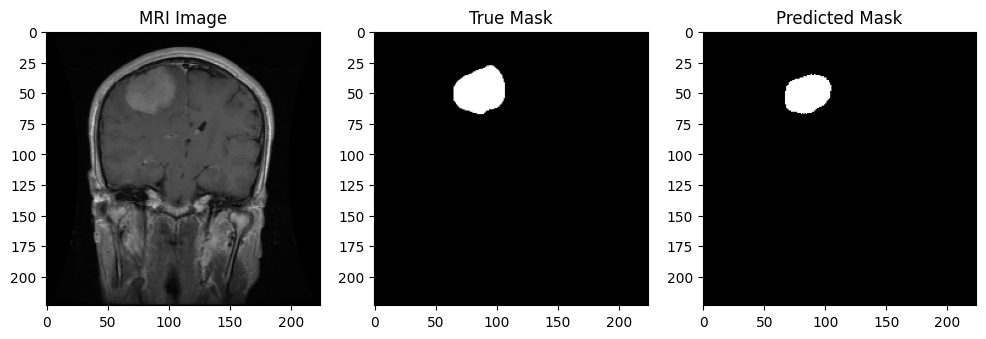

In [22]:
from matplotlib import pyplot as plt

index = 5

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("MRI Image")
plt.imshow(X_test[index])

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(y_test[index].squeeze(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred_mask[index].squeeze(), cmap="gray")

plt.show()